In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pylab import *
from sklearn.preprocessing import MinMaxScaler
from sklearn import svm, datasets

In [8]:
def createClusteredData(N,K):
    np.random.seed(1234)
    # define a aleatoriedade fixa dos dados
    pointsPerCluster = float(N)/K
    # define quantos dados vao ter cada cluster
    X =[]
    y=[]
    for i in range(K):
        incomeCentroid = np.random.uniform(20000.0, 200000.0)
        # valor dos dados que vao estar no cluster
        ageCentroid = np.random.uniform(20.0, 70.0)
        for j in range(int(pointsPerCluster)):
            X.append([np.random.normal(incomeCentroid, 100000.0),np.random.normal(ageCentroid, 2.0)])
            # para cada ponto no cluster ele adiciona um valor de renda e de idade
            y.append(i)
    X = np.array(X)
    # transforma em array numpy
    y=np.array(y)
    return X, y

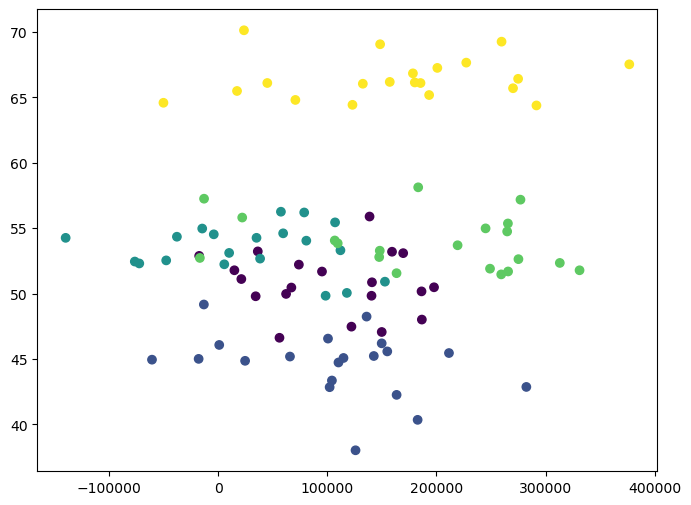

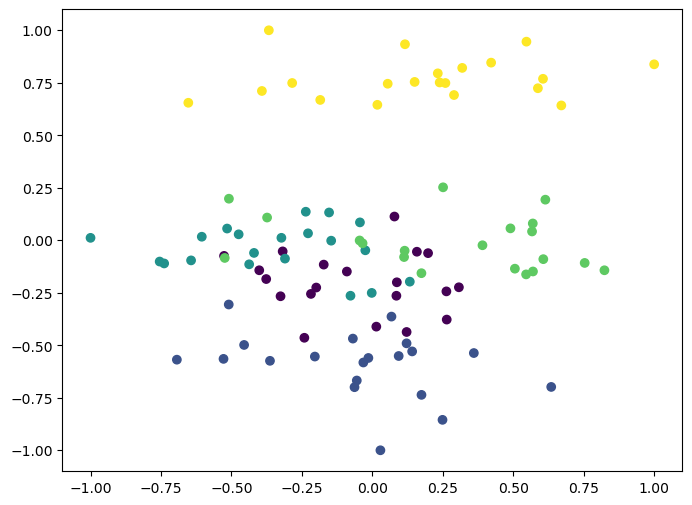

In [ ]:
(X, y) = createClusteredData(100, 5)
#chama a função para criar os dados 

plt.figure(figsize=(8, 6))
plt.scatter(X[:,0], X[:,1], c=y.astype(float))
plt.show()

scaling = MinMaxScaler(feature_range=(-1,1)).fit(X)
X = scaling.transform(X)
# transforma os dados em uma escala de -1 a 1

plt.figure(figsize=(8, 6))
plt.scatter(X[:,0], X[:,1], c=y.astype(float))
plt.show()

In [ ]:
C =1.0
svc = svm.SVC(kernel='linear', C=C).fit(X,y)
# treina o modelo svm com kernel linear, e taxa de aprendizado

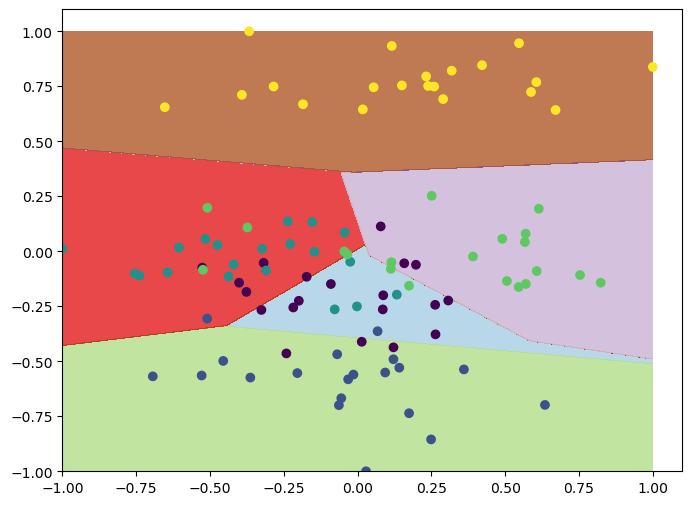

In [ ]:
def plotPredictions(clf):
    
    xx, yy = np.meshgrid(np.arange(-1, 1, .001), np.arange(-1, 1, .001))
    # cria um grid numpy com range de -1 a 1

    
    npx = xx.ravel()
    npy = yy.ravel()
    #converte para array numpy

    
    samplePoints = np.c_[npx, npy]

    s#salva os dados de predição
    Z = clf.predict(samplePoints)

    plt.figure(figsize=(8, 6))
    Z = Z.reshape(xx.shape) #Reshape results to match xx dimension
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8) # Draw the contour
    plt.scatter(X[:,0], X[:,1], c=y.astype(float)) # Draw the points
    plt.show()

plotPredictions(svc)

In [ ]:
print(svc.predict(scaling.transform([[200000, 40]])))
# predição simples

[1]


In [ ]:
print(svc.predict(scaling.transform([[50000, 65]])))
predição simples

[4]
